<h1>Titanic Using SciKit-Learn</h1>

<h4>Libraries Used</h4>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import torch
import tensorflow as tf


from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import  cross_val_score, StratifiedKFold, train_test_split, GridSearchCV


I0000 00:00:1781425731.884396   32409 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781425740.786681   32409 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


<h4>Importing CSVs into dataframes</h4>

In [3]:
train_df = pd.read_csv('/home/vansh/Desktop/Code/SKLearn Projects/train.csv')
test_df = pd.read_csv('/home/vansh/Desktop/Code/SKLearn Projects/test.csv')

In [4]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train_df.describe(include=['O'])

/tmp/ipykernel_32409/2257617226.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_df.describe(include=['O'])


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


<h4>Group By Method: Using mean to get an idea of how many people of that particular value of category survived.</h4>

In [7]:
train_df.groupby(['Pclass'], as_index=False)['Survived'].mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [8]:
train_df.groupby(['Sex'], as_index=False)['Survived'].mean()

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [9]:
train_df.groupby(['SibSp'], as_index=False)['Survived'].mean()

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [10]:
train_df.groupby(['Parch'], as_index=False)['Survived'].mean()

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.600000
4,4,0.000000
5,5,0.200000
6,6,0.000000


<h4>Creating new column by using other columns</h4>

In [11]:
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1


In [12]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,5
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,3
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,2


<h4>Seeing how family size impacts the chances of survival</h4>

In [13]:
train_df.groupby(['Family_Size'], as_index=False)['Survived'].mean()

,Family_Size,Survived
0,1,0.303538
1,2,0.552795
2,3,0.578431
3,4,0.724138
4,5,0.200000
5,6,0.136364
6,7,0.333333
7,8,0.000000
8,11,0.000000


<h4>Creating a family map:</h4>
<ul>
<li>Groups similar family sizes together so the model can find patterns more easily.</li>
<li>Reduces noise by combining rare family sizes into larger categories.</li>
<li>Helps simple machine learning models learn relationships better.</li>
<li>Makes the feature easier for humans to understand and explain.</li>
<li>Can improve prediction accuracy when exact numbers are less important than the group they belong to.</li>
</ul>

In [14]:
family_map = {1: 'Alone', 2: 'Small', 3: 'Small', 4:'Small', 5: 'Medium', 6:'Medium', 7:'Large', 8:'Large', 11:'Large'}
train_df['Family_Size_Grouped'] = train_df['Family_Size'].map(family_map)
test_df['Family_Size_Grouped'] = train_df['Family_Size'].map(family_map)

In [15]:
train_df.groupby(['Family_Size_Grouped'], as_index=False)['Survived'].mean()

,Family_Size_Grouped,Survived
0,Alone,0.303538
1,Large,0.160000
2,Medium,0.162162
3,Small,0.578767


In [16]:
train_df.groupby(['Embarked'], as_index=False)['Survived'].mean()

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.336957


<h3>Using Seaborn Library to plot a histogram</h3>

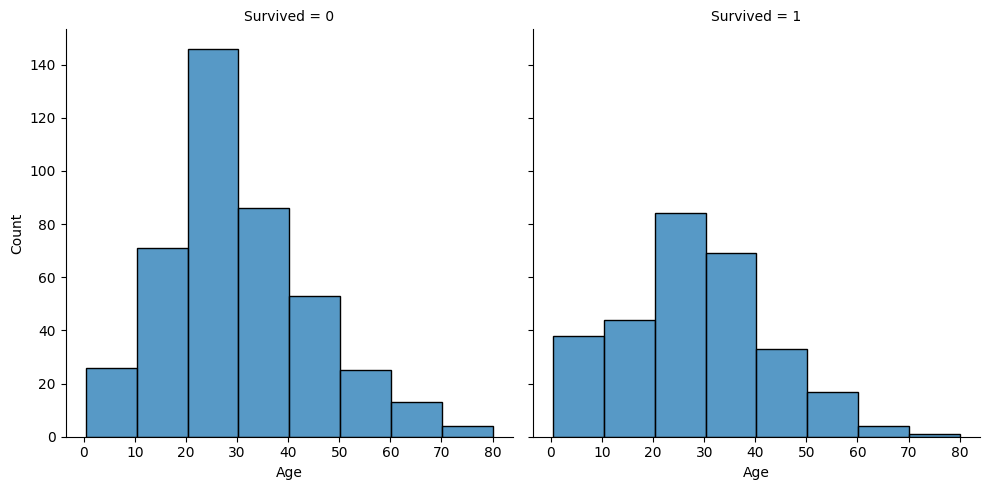

In [17]:
sns.displot(train_df, x='Age', col = 'Survived', binwidth = 10, height = 5)

<h5>Creating Age Groups</h5>

<p>
The <code>Age</code> feature is divided into 8 equally populated groups using <code>pd.qcut()</code>.
This helps uncover age-based patterns and simplifies the feature for machine learning models.
</p>

In [18]:
train_df['Age_Cut'] = pd.qcut(train_df['Age'], 8)
test_df['Age_Cut'] = pd.qcut(test_df['Age'], 8)

In [19]:
train_df.groupby(['Age_Cut'], as_index=False)['Survived'].mean()

,Age_Cut,Survived
0,"(0.419, 16.0]",0.550000
1,"(16.0, 20.125]",0.341772
2,"(20.125, 24.0]",0.367347
3,"(24.0, 28.0]",0.352941
4,"(28.0, 32.312]",0.416667
5,"(32.312, 38.0]",0.450549
6,"(38.0, 47.0]",0.329545
7,"(47.0, 80.0]",0.415730


<h5>Converting Age Groups into Numerical Categories</h5>

<p>
Based on the age ranges identified during age binning, the <code>Age</code> feature is transformed
into ordinal categories ranging from 0 to 4. This simplifies the feature, reduces the impact of
outliers, and makes it easier for machine learning models to learn age-related patterns.
</p>

In [20]:
train_df.loc[train_df['Age'] <= 19, 'Age'] = 0
train_df.loc[(train_df['Age'] > 19) & (train_df['Age'] <= 25), 'Age'] = 1
train_df.loc[(train_df['Age'] > 25) & (train_df['Age'] <= 31.8), 'Age'] = 2
train_df.loc[(train_df['Age'] > 31.8) & (train_df['Age'] <= 41), 'Age'] = 3
train_df.loc[(train_df['Age'] > 41) & (train_df['Age'] <= 80), 'Age'] = 4
train_df.loc[train_df['Age'] > 80, 'Age']

test_df.loc[test_df['Age'] <= 19, 'Age'] = 0
test_df.loc[(test_df['Age'] > 19) & (test_df['Age'] <= 25), 'Age'] = 1
test_df.loc[(test_df['Age'] > 25) & (test_df['Age'] <= 31.8), 'Age'] = 2
test_df.loc[(test_df['Age'] > 31.8) & (test_df['Age'] <= 41), 'Age'] = 3
test_df.loc[(test_df['Age'] > 41) & (test_df['Age'] <= 80), 'Age'] = 4
test_df.loc[test_df['Age'] > 80, 'Age']

Series([], Name: Age, dtype: float64)

In [21]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Family_Size_Grouped,Age_Cut
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,1,0,A/5 21171,7.2500,NaN,S,2,Small,"(20.125, 24.0]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,3.0,1,0,PC 17599,71.2833,C85,C,2,Small,"(32.312, 38.0]"
2,3,1,3,"Heikkinen, Miss. Laina",female,2.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Alone,"(24.0, 28.0]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,3.0,1,0,113803,53.1000,C123,S,2,Small,"(32.312, 38.0]"
4,5,0,3,"Allen, Mr. William Henry",male,3.0,0,0,373450,8.0500,NaN,S,1,Alone,"(32.312, 38.0]"


<h5>Analyzing the Impact of Fare on Survival</h5>

<p>
A histogram of the <code>Fare</code> feature is used to compare fare distributions between survivors and non-survivors. The visualization suggests that passengers who paid higher fares were more likely to survive, indicating that fare may be an important predictor of survival. Based on these observations, the fare feature can be grouped into categories to simplify the data and improve model performance.
</p>

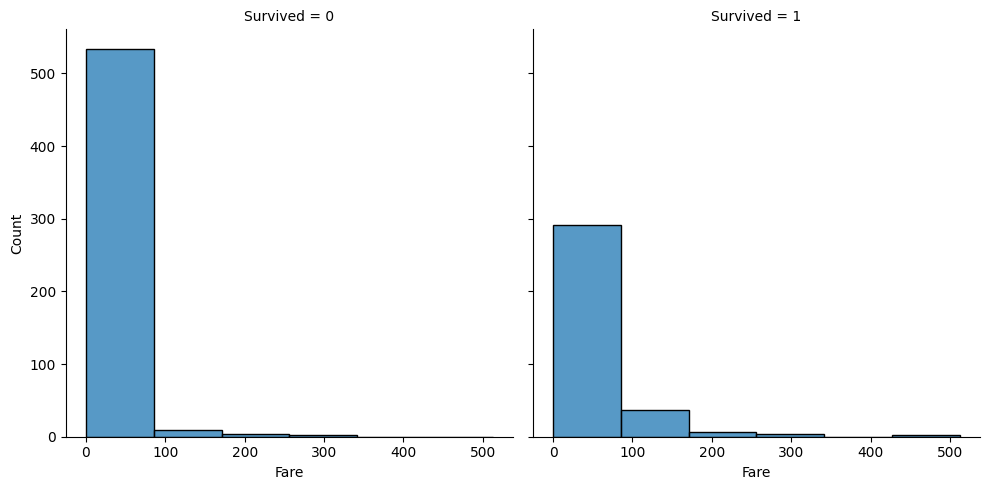

In [22]:
sns.displot(train_df, x='Fare', col='Survived', binwidth=80, height=5)

<h5>Encoding Fare Groups</h5>

<p>
The binned fare ranges are converted into numerical categories (0–4), enabling machine learning models to process fare information more effectively.
</p>

In [23]:
train_df.loc[train_df['Fare'] <= 7.854, 'Fare'] = 0
train_df.loc[(train_df['Fare'] > 7.854) & (train_df['Fare'] <= 10.5), 'Fare'] = 1
train_df.loc[(train_df['Fare'] > 10.5) & (train_df['Fare'] <= 21.679), 'Fare'] = 2
train_df.loc[(train_df['Fare'] > 21.679) & (train_df['Fare'] <= 39.688), 'Fare'] = 3
train_df.loc[(train_df['Fare'] > 39.688) & (train_df['Fare'] <= 512.329), 'Fare'] = 4
train_df.loc[train_df['Fare'] > 512.329, 'Fare']

test_df.loc[test_df['Fare'] <= 7.854, 'Fare'] = 0
test_df.loc[(test_df['Fare'] > 7.854) & (test_df['Fare'] <= 10.5), 'Fare'] = 1
test_df.loc[(test_df['Fare'] > 10.5) & (test_df['Fare'] <= 21.679), 'Fare'] = 2
test_df.loc[(test_df['Fare'] > 21.679) & (test_df['Fare'] <= 39.688), 'Fare'] = 3
test_df.loc[(test_df['Fare'] > 39.688) & (test_df['Fare'] <= 512.329), 'Fare'] = 4
test_df.loc[test_df['Fare'] > 512.329, 'Fare']

343    512.3292
Name: Fare, dtype: float64

In [24]:
train_df['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

<h5>Extracting Passenger Titles from Names</h5>

<p>
The <code>Name</code> column contains valuable information such as passenger titles (e.g., <code>Mr</code>, <code>Mrs</code>, <code>Miss</code>, <code>Master</code>). This step extracts these titles and stores them in a new feature called <code>Title</code>.

The extraction process begins by applying <code>str.split(pat=",", expand=True)</code> to the <code>Name</code> column. Here, the <code>pat</code> parameter specifies the delimiter used for splitting the string, which is a comma (<code>,</code>). Since Titanic names are stored in the format <code>"Last Name, Title. First Name"</code>, splitting at the comma separates the surname from the remaining part of the name. The parameter <code>expand=True</code> instructs Pandas to return the result as separate columns rather than a list, making it easier to access individual components.

After selecting the text that appears after the comma, the code applies another split operation using <code>str.split(pat=".", expand=True)</code>. In this case, the <code>pat</code> parameter is a period (<code>.</code>), which separates the title from the passenger's given names. Again, <code>expand=True</code> converts the result into separate columns, allowing the title to be selected directly.

The final step uses <code>apply(lambda x: x.strip())</code>. The <code>apply()</code> function applies an operation to every value in the column. The keyword <code>lambda</code> is used to create a small anonymous function that takes each title as input (<code>x</code>) and applies the <code>strip()</code> method. The <code>strip()</code> method removes any leading or trailing whitespace, ensuring that titles such as <code>" Mr"</code> are converted to <code>"Mr"</code>.

For example, the name <code>"Braund, Mr. Owen Harris"</code> is processed as follows:
<ul>
    <li>Split at the comma → <code>["Braund", " Mr. Owen Harris"]</code></li>
    <li>Select the second part → <code>" Mr. Owen Harris"</code></li>
    <li>Split at the period → <code>[" Mr", " Owen Harris"]</code></li>
    <li>Select the first part → <code>" Mr"</code></li>
    <li>Apply <code>strip()</code> → <code>"Mr"</code></li>
</ul>

The extracted title is then stored in a new column called <code>Title</code>. The same procedure is performed on both the training and testing datasets to ensure consistency. Since titles often provide information about a passenger's gender, age group, and social status, this engineered feature can help the machine learning model identify important survival patterns.
</p>

In [25]:
train_df['Title'] = train_df['Name'].str.split(pat= ",", expand=True)[1].str.split(pat= ".", expand=True)[0].apply(lambda x: x.strip())
test_df['Title'] = test_df['Name'].str.split(pat= ",", expand=True)[1].str.split(pat= ".", expand=True)[0].apply(lambda x: x.strip())

In [26]:
train_df.groupby(['Title'], as_index=False)['Survived'].mean()


,Title,Survived
0,Capt,0.000000
1,Col,0.500000
2,Don,0.000000
3,Dr,0.428571
4,Jonkheer,0.000000
5,Lady,1.000000
6,Major,0.500000
7,Master,0.575000
8,Miss,0.697802
9,Mlle,1.000000


<h5>Grouping Rare Titles into Broader Categories</h5>

<p>
After extracting passenger titles from the <code>Name</code> column, some titles occur very infrequently in the dataset. Machine learning models often perform better when rare categories are grouped into broader, more meaningful categories rather than being treated as separate values.

This step uses the <code>replace()</code> function to map multiple rare titles to common groups. The <code>replace()</code> method takes a dictionary where each key represents an existing title and each value represents the new category that will replace it.

Military-related titles such as <code>Capt</code>, <code>Col</code>, and <code>Major</code> are grouped into a single category called <code>Military</code>. Similarly, noble, aristocratic, and uncommon titles such as <code>Jonkheer</code>, <code>the Countess</code>, <code>Don</code>, <code>Lady</code>, and <code>Sir</code> are grouped into the category <code>Noble</code>. French title variations such as <code>Mlle</code>, <code>Ms</code>, and <code>Mme</code> are also mapped to <code>Noble</code> to reduce the number of unique title categories.

For example:
<ul>
    <li><code>Capt</code> → <code>Military</code></li>
    <li><code>Col</code> → <code>Military</code></li>
    <li><code>Major</code> → <code>Military</code></li>
    <li><code>Lady</code> → <code>Noble</code></li>
    <li><code>Sir</code> → <code>Noble</code></li>
    <li><code>the Countess</code> → <code>Noble</code></li>
</ul>

By reducing the number of unique title values, the dataset becomes less sparse and patterns associated with social status or profession become easier for the machine learning model to learn. This transformation is applied to both the training and testing datasets to maintain consistency between them.
</p>

In [27]:
train_df['Title'] = train_df['Title'].replace({
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Jonkheer': 'Noble',
    'the Countess':'Noble',
    'Don': 'Noble',
    'Lady': 'Noble',
    'Sir': 'Noble',
    'Mlle': 'Noble',
    'Ms': 'Noble',
    'Mme': 'Noble'
})


test_df['Title'] = test_df['Title'].replace({
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Jonkheer': 'Noble',
    'the Countess':'Noble',
    'Don': 'Noble',
    'Lady': 'Noble',
    'Sir': 'Noble',
    'Mlle': 'Noble',
    'Ms': 'Noble',
    'Mme': 'Noble'
})

<h5>Analyzing Survival Rates Across Passenger Titles</h5>

<p>
After extracting and grouping passenger titles, the survival rate of each title category is analyzed using the count of passengers and the mean survival rate. The results show that titles contain valuable information related to survival outcomes.

The title <code>Mr</code> is the most common category in the dataset, but it has the lowest survival rate among the major groups, indicating that adult males were less likely to survive. In contrast, <code>Mrs</code> and <code>Miss</code> exhibit significantly higher survival rates, supporting the historical observation that women were given priority during evacuation. The <code>Master</code> title, typically assigned to young boys, also shows a relatively high survival rate.

Several titles such as <code>Military</code>, <code>Noble</code>, <code>Dr</code>, and <code>Rev</code> appear only a small number of times. Because these categories contain very few observations, their survival rates may be unstable and less representative of the overall population. Grouping rare titles into broader categories reduces the number of unique values, minimizes noise, and enables the machine learning model to learn more reliable patterns from the data.

Overall, the analysis confirms that passenger title is a meaningful feature because it indirectly captures information about gender, age, profession, and social status, all of which influence survival probability.
</p>

In [28]:
train_df.groupby(['Title'], as_index=False)['Survived'].agg(['count', 'mean'])

,Title,count,mean
0,Dr,7,0.428571
1,Master,40,0.575000
2,Military,5,0.400000
3,Miss,182,0.697802
4,Mr,517,0.156673
5,Mrs,125,0.792000
6,Noble,9,0.777778
7,Rev,6,0.000000


<h5>Exploring Name Length as a Feature</h5>

<p>
A KDE plot is used to compare the distribution of name lengths for survivors and non-survivors. The results suggest that passengers with longer names were slightly more likely to survive, possibly due to their association with titles, social status, or higher passenger classes. This indicates that <code>Name_Length</code> may provide additional predictive information for the machine learning model.
</p>

In [29]:
train_df['Name_Length'] = train_df['Name'].apply(lambda x: len(x))
test_df['Name_Length'] = test_df['Name'].apply(lambda x: len(x))

In [30]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Family_Size_Grouped,Age_Cut,Title,Name_Length
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,1,0,A/5 21171,0.0,NaN,S,2,Small,"(20.125, 24.0]",Mr,23
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,3.0,1,0,PC 17599,4.0,C85,C,2,Small,"(32.312, 38.0]",Mrs,51
2,3,1,3,"Heikkinen, Miss. Laina",female,2.0,0,0,STON/O2. 3101282,1.0,NaN,S,1,Alone,"(24.0, 28.0]",Miss,22
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,3.0,1,0,113803,4.0,C123,S,2,Small,"(32.312, 38.0]",Mrs,44
4,5,0,3,"Allen, Mr. William Henry",male,3.0,0,0,373450,1.0,NaN,S,1,Alone,"(32.312, 38.0]",Mr,24


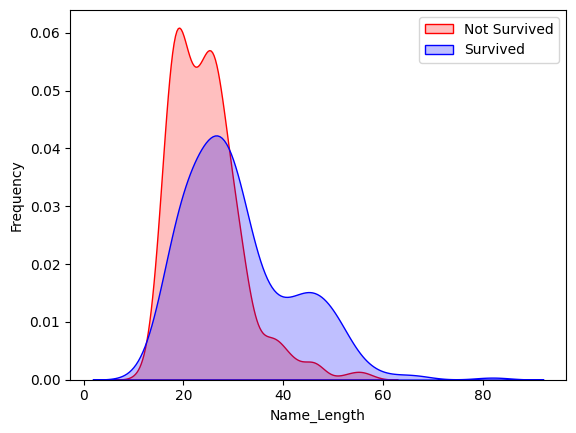

In [31]:
g = sns.kdeplot(train_df['Name_Length'][(train_df['Survived'] == 0) & (train_df['Name_Length'].notnull())], color='Red', fill=True)
g = sns.kdeplot(train_df['Name_Length'][(train_df['Survived'] == 1) & (train_df['Name_Length'].notnull())], ax=g, color='Blue', fill=True)
g.set_xlabel('Name_Length')
g.set_ylabel('Frequency')
g = g.legend(['Not Survived', 'Survived'])


In [32]:
train_df['Name_LengthGB'] = pd.qcut(train_df['Name_Length'], 8)
test_df['Name_LengthGB'] = pd.qcut(test_df['Name_Length'], 8)

<h5>Creating and Encoding Name Length Groups</h5>

<p>
The <code>Name_Length</code> feature is divided into eight quantile-based groups using <code>pd.qcut()</code> to analyze its relationship with survival. The results show that survival rates generally increase as name length increases, indicating that this feature contains useful predictive information. Based on these intervals, name lengths are converted into ordinal categories (<code>0–7</code>) using <code>loc</code>, making the feature easier for machine learning models to process while preserving the observed survival patterns.
</p>

In [33]:
train_df.groupby(['Name_LengthGB'], as_index=False)['Survived'].mean()

,Name_LengthGB,Survived
0,"(11.999, 18.0]",0.214286
1,"(18.0, 20.0]",0.252427
2,"(20.0, 23.0]",0.307692
3,"(23.0, 25.0]",0.346939
4,"(25.0, 27.25]",0.292929
5,"(27.25, 30.0]",0.428571
6,"(30.0, 38.0]",0.517241
7,"(38.0, 82.0]",0.745283


In [34]:
train_df.loc[train_df['Name_Length'] <= 18, 'Name_Size'] = 0
train_df.loc[(train_df['Name_Length'] > 18) & (train_df['Name_Length'] <= 20), 'Name_Size'] = 1
train_df.loc[(train_df['Name_Length'] > 20) & (train_df['Name_Length'] <= 23), 'Name_Size'] = 2
train_df.loc[(train_df['Name_Length'] > 23) & (train_df['Name_Length'] <= 25), 'Name_Size'] = 3
train_df.loc[(train_df['Name_Length'] > 25) & (train_df['Name_Length'] <= 27.25), 'Name_Size'] = 4
train_df.loc[(train_df['Name_Length'] > 27.25) & (train_df['Name_Length'] <= 30), 'Name_Size'] = 5
train_df.loc[(train_df['Name_Length'] > 30) & (train_df['Name_Length'] <= 38), 'Name_Size'] = 6
train_df.loc[(train_df['Name_Length'] > 38) & (train_df['Name_Length'] <= 82), 'Name_Size'] = 7
train_df.loc[train_df['Name_Length'] > 82, 'Name_Size']

Series([], Name: Name_Size, dtype: float64)

In [35]:
test_df.loc[test_df['Name_Length'] <= 18, 'Name_Size'] = 0
test_df.loc[(test_df['Name_Length'] > 18) & (test_df['Name_Length'] <= 20), 'Name_Size'] = 1
test_df.loc[(test_df['Name_Length'] > 20) & (test_df['Name_Length'] <= 23), 'Name_Size'] = 2
test_df.loc[(test_df['Name_Length'] > 23) & (test_df['Name_Length'] <= 25), 'Name_Size'] = 3
test_df.loc[(test_df['Name_Length'] > 25) & (test_df['Name_Length'] <= 27.25), 'Name_Size'] = 4
test_df.loc[(test_df['Name_Length'] > 27.25) & (test_df['Name_Length'] <= 30), 'Name_Size'] = 5
test_df.loc[(test_df['Name_Length'] > 30) & (test_df['Name_Length'] <= 38), 'Name_Size'] = 6
test_df.loc[(test_df['Name_Length'] > 38) & (test_df['Name_Length'] <= 82), 'Name_Size'] = 7
test_df.loc[test_df['Name_Length'] > 82, 'Name_Size']

Series([], Name: Name_Size, dtype: float64)

In [36]:
train_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Family_Size_Grouped,Age_Cut,Title,Name_Length,Name_LengthGB,Name_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,1,0,A/5 21171,0.0,NaN,S,2,Small,"(20.125, 24.0]",Mr,23,"(20.0, 23.0]",2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,3.0,1,0,PC 17599,4.0,C85,C,2,Small,"(32.312, 38.0]",Mrs,51,"(38.0, 82.0]",7.0
2,3,1,3,"Heikkinen, Miss. Laina",female,2.0,0,0,STON/O2. 3101282,1.0,NaN,S,1,Alone,"(24.0, 28.0]",Miss,22,"(20.0, 23.0]",2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,3.0,1,0,113803,4.0,C123,S,2,Small,"(32.312, 38.0]",Mrs,44,"(38.0, 82.0]",7.0
4,5,0,3,"Allen, Mr. William Henry",male,3.0,0,0,373450,1.0,NaN,S,1,Alone,"(32.312, 38.0]",Mr,24,"(23.0, 25.0]",3.0


In [37]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Family_Size_Grouped,Age_Cut,Title,Name_Length,Name_LengthGB,Name_Size
0,892,3,"Kelly, Mr. James",male,3.0,0,0,330911,0.0,NaN,Q,2,Small,"(32.0, 39.0]",Mr,16,"(12.999, 18.0]",0.0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,4.0,1,0,363272,0.0,NaN,S,2,Small,"(39.0, 48.0]",Mrs,32,"(30.75, 41.0]",6.0
2,894,2,"Myles, Mr. Thomas Francis",male,4.0,0,0,240276,1.0,NaN,Q,1,Alone,"(48.0, 76.0]",Mr,25,"(23.0, 25.0]",3.0
3,895,3,"Wirz, Mr. Albert",male,2.0,0,0,315154,1.0,NaN,S,2,Small,"(24.0, 27.0]",Mr,16,"(12.999, 18.0]",0.0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,1.0,1,1,3101298,2.0,NaN,S,1,Alone,"(21.0, 24.0]",Mrs,44,"(41.0, 63.0]",7.0


<h5>Extracting Ticket Information and Creating Ticket Frequency Features</h5>

<p>
The <code>Ticket</code> feature is further analyzed to extract information that may be useful for predicting survival. First, the ticket number is isolated by splitting each ticket string and selecting its last component, which is stored in a new feature called <code>Ticket_Number</code>. This helps separate the numerical portion of the ticket from any prefixes or codes.

Next, the dataset is grouped by <code>Ticket_Number</code> to examine the number of passengers associated with each ticket and their corresponding survival rates. This analysis helps identify whether passengers sharing the same ticket exhibit similar survival patterns.

The <code>transform('count')</code> function is then used to create a new feature called <code>TicketNumberCounts</code>, which records how many times each ticket number appears in the dataset. Since passengers traveling together often shared the same ticket, this feature can indirectly capture group travel behavior and family or companion relationships that are not fully represented by other features.

The same transformations are applied to both the training and testing datasets to ensure consistency. By extracting ticket-related information and creating a ticket frequency feature, the model gains additional context about passenger groups, which may improve its ability to predict survival outcomes.
</p>

In [38]:
train_df['Ticket_Number'] = train_df['Ticket'].apply(lambda x: pd.Series({'Ticket': x.split()[-1]}))

In [39]:
test_df['Ticket_Number'] = test_df['Ticket'].apply(lambda x: x.split()[-1])
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Family_Size_Grouped,Age_Cut,Title,Name_Length,Name_LengthGB,Name_Size,Ticket_Number
0,892,3,"Kelly, Mr. James",male,3.0,0,0,330911,0.0,NaN,Q,2,Small,"(32.0, 39.0]",Mr,16,"(12.999, 18.0]",0.0,330911
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,4.0,1,0,363272,0.0,NaN,S,2,Small,"(39.0, 48.0]",Mrs,32,"(30.75, 41.0]",6.0,363272
2,894,2,"Myles, Mr. Thomas Francis",male,4.0,0,0,240276,1.0,NaN,Q,1,Alone,"(48.0, 76.0]",Mr,25,"(23.0, 25.0]",3.0,240276
3,895,3,"Wirz, Mr. Albert",male,2.0,0,0,315154,1.0,NaN,S,2,Small,"(24.0, 27.0]",Mr,16,"(12.999, 18.0]",0.0,315154
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,1.0,1,1,3101298,2.0,NaN,S,1,Alone,"(21.0, 24.0]",Mrs,44,"(41.0, 63.0]",7.0,3101298


In [40]:
train_df.groupby(['Ticket_Number'], as_index=False)['Survived'].agg(['count', 'mean']).sort_values('count', ascending=False)

,Ticket_Number,count,mean
94,1601,7,0.714286
196,2343,7,0.000000
464,347082,7,0.000000
468,347088,6,0.000000
358,3101295,6,0.000000
...,...,...,...
276,2667,1,1.000000
278,2669,1,0.000000
279,26707,1,0.000000
280,2671,1,0.000000


In [41]:
train_df.groupby('Ticket_Number')['Ticket_Number'].transform('count')

0      1
1      1
2      1
3      2
4      1
      ..
886    1
887    1
888    2
889    1
890    1
Name: Ticket_Number, Length: 891, dtype: int64

In [42]:
train_df['TicketNumberCounts'] = train_df.groupby('Ticket_Number')['Ticket_Number'].transform('count')


In [43]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Embarked,Family_Size,Family_Size_Grouped,Age_Cut,Title,Name_Length,Name_LengthGB,Name_Size,Ticket_Number,TicketNumberCounts
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,1,0,A/5 21171,0.0,...,S,2,Small,"(20.125, 24.0]",Mr,23,"(20.0, 23.0]",2.0,21171,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,3.0,1,0,PC 17599,4.0,...,C,2,Small,"(32.312, 38.0]",Mrs,51,"(38.0, 82.0]",7.0,17599,1
2,3,1,3,"Heikkinen, Miss. Laina",female,2.0,0,0,STON/O2. 3101282,1.0,...,S,1,Alone,"(24.0, 28.0]",Miss,22,"(20.0, 23.0]",2.0,3101282,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,3.0,1,0,113803,4.0,...,S,2,Small,"(32.312, 38.0]",Mrs,44,"(38.0, 82.0]",7.0,113803,2
4,5,0,3,"Allen, Mr. William Henry",male,3.0,0,0,373450,1.0,...,S,1,Alone,"(32.312, 38.0]",Mr,24,"(23.0, 25.0]",3.0,373450,1


In [44]:
train_df = train_df.drop(columns=['TicketNumberCounts'])


In [45]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Family_Size_Grouped,Age_Cut,Title,Name_Length,Name_LengthGB,Name_Size,Ticket_Number
0,892,3,"Kelly, Mr. James",male,3.0,0,0,330911,0.0,NaN,Q,2,Small,"(32.0, 39.0]",Mr,16,"(12.999, 18.0]",0.0,330911
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,4.0,1,0,363272,0.0,NaN,S,2,Small,"(39.0, 48.0]",Mrs,32,"(30.75, 41.0]",6.0,363272
2,894,2,"Myles, Mr. Thomas Francis",male,4.0,0,0,240276,1.0,NaN,Q,1,Alone,"(48.0, 76.0]",Mr,25,"(23.0, 25.0]",3.0,240276
3,895,3,"Wirz, Mr. Albert",male,2.0,0,0,315154,1.0,NaN,S,2,Small,"(24.0, 27.0]",Mr,16,"(12.999, 18.0]",0.0,315154
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,1.0,1,1,3101298,2.0,NaN,S,1,Alone,"(21.0, 24.0]",Mrs,44,"(41.0, 63.0]",7.0,3101298


In [46]:
train_df['TicketNumberCounts'] = train_df.groupby('Ticket_Number')['Ticket_Number'].transform('count')
test_df['TicketNumberCounts'] = test_df.groupby('Ticket_Number')['Ticket_Number'].transform('count')

In [47]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Family_Size_Grouped,Age_Cut,Title,Name_Length,Name_LengthGB,Name_Size,Ticket_Number,TicketNumberCounts
0,892,3,"Kelly, Mr. James",male,3.0,0,0,330911,0.0,NaN,Q,2,Small,"(32.0, 39.0]",Mr,16,"(12.999, 18.0]",0.0,330911,1
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,4.0,1,0,363272,0.0,NaN,S,2,Small,"(39.0, 48.0]",Mrs,32,"(30.75, 41.0]",6.0,363272,1
2,894,2,"Myles, Mr. Thomas Francis",male,4.0,0,0,240276,1.0,NaN,Q,1,Alone,"(48.0, 76.0]",Mr,25,"(23.0, 25.0]",3.0,240276,1
3,895,3,"Wirz, Mr. Albert",male,2.0,0,0,315154,1.0,NaN,S,2,Small,"(24.0, 27.0]",Mr,16,"(12.999, 18.0]",0.0,315154,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,1.0,1,1,3101298,2.0,NaN,S,1,Alone,"(21.0, 24.0]",Mrs,44,"(41.0, 63.0]",7.0,3101298,1


In [48]:
train_df.groupby(['TicketNumberCounts'], as_index=False)['Survived'].agg(['count', 'mean']).sort_values('count')

,TicketNumberCounts,count,mean
4,5,10,0.000000
5,6,18,0.000000
6,7,21,0.238095
3,4,44,0.500000
2,3,66,0.712121
1,2,188,0.569149
0,1,544,0.295956


In [49]:
print(train_df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family_Size', 'Family_Size_Grouped', 'Age_Cut', 'Title', 'Name_Length', 'Name_LengthGB', 'Name_Size', 'Ticket_Number', 'TicketNumberCounts']


<h5>Extracting and Standardizing Ticket Prefix Information</h5>

<p>
After analyzing ticket numbers and ticket frequencies, the ticket prefixes are explored to determine whether they contain additional information related to passenger characteristics. The <code>Ticket</code> feature is split using <code>str.split(pat=" ", expand=True)</code>, where <code>pat</code> specifies a space as the delimiter and <code>expand=True</code> returns the results as separate columns. For tickets containing a prefix, the prefix is extracted and stored in a new feature called <code>TicketLocation</code>. Tickets without a prefix are assigned a default value using <code>np.where()</code>.

The distribution of these prefixes is then examined using <code>value_counts()</code>. Since many prefixes represent the same ticket office or booking location but appear in different formats, the <code>replace()</code> function is used to standardize them. For example, variations such as <code>SOTON/O.Q.</code> and <code>SOTON/OQ</code> are merged into a single category, while similar forms of <code>CA</code>, <code>SC/Paris</code>, <code>A/4</code>, <code>A/5</code>, and <code>W/C</code> are also consolidated.

This preprocessing step reduces the number of unique categories, removes inconsistencies in the data, and creates a cleaner feature that may help the machine learning model capture patterns associated with ticket origin, booking office, or passenger grouping.
</p>

In [50]:
train_df['Ticket'].str.split(pat=" ", expand=True)

,0,1,2
0,A/5,21171,NaN
1,PC,17599,NaN
2,STON/O2.,3101282,NaN
3,113803,NaN,NaN
4,373450,NaN,NaN
...,...,...,...
886,211536,NaN,NaN
887,112053,NaN,NaN
888,W./C.,6607,NaN
889,111369,NaN,NaN


In [51]:
train_df['TicketLocation'] = np.where(train_df['Ticket'].str.split(pat=" ", expand=True)[1].notna(), train_df['Ticket'].str.split(pat=" ", expand=True)[0].apply(lambda x: x.strip()), 'Blank')
test_df['TicketLocation'] = np.where(test_df['Ticket'].str.split(pat=" ", expand=True)[1].notna(), test_df['Ticket'].str.split(pat=" ", expand=True)[0].apply(lambda x: x.strip()), 'Blank')

In [52]:
train_df['TicketLocation']

0           A/5
1            PC
2      STON/O2.
3         Blank
4         Blank
         ...   
886       Blank
887       Blank
888       W./C.
889       Blank
890       Blank
Name: TicketLocation, Length: 891, dtype: str

In [53]:
train_df['TicketLocation'].value_counts()

TicketLocation
Blank         665
PC             60
C.A.           27
STON/O         12
A/5            10
W./C.           9
SOTON/O.Q.      8
CA.             8
A/5.            7
SOTON/OQ        7
STON/O2.        6
CA              6
S.O.C.          5
C               5
SC/PARIS        5
F.C.C.          5
SC/Paris        4
PP              3
A/4.            3
SC/AH           3
A/4             3
S.O./P.P.       3
A./5.           2
A.5.            2
P/PP            2
WE/P            2
SOTON/O2        2
S.C./PARIS      2
S.C./A.4.       1
S.P.            1
SO/C            1
W.E.P.          1
A4.             1
S.O.P.          1
Fa              1
W/C             1
SW/PP           1
SCO/W           1
SC              1
A/S             1
S.W./PP         1
F.C.            1
C.A./SOTON      1
Name: count, dtype: int64

In [54]:
train_df['TicketLocation'] = train_df['TicketLocation'].replace(
    {
        'SOTON/O.Q.':'SOTON/OQ',
        'C.A.':'CA',
        'CA.':'CA',
        'SC/PARIS':'SC/Paris',
        'S.C./PARIS':'SC/Paris',
        'A/4.':'A/4',
        'A/5.':'A/5',
        'A.5.':'A/5',
        'A./5.':'A/5',
        'W./C.':'W/C',
    }
)


test_df['TicketLocation'] = test_df['TicketLocation'].replace(
    {
        'SOTON/O.Q.':'SOTON/OQ',
        'C.A.':'CA',
        'CA.':'CA',
        'SC/PARIS':'SC/Paris',
        'S.C./PARIS':'SC/Paris',
        'A/4.':'A/4',
        'A/5.':'A/5',
        'A.5.':'A/5',
        'A./5.':'A/5',
        'W./C.':'W/C',
    }
)

In [55]:
train_df.groupby(['TicketLocation'], as_index=False)['Survived'].agg(['count', 'mean']).sort_values('count', ascending=True)

,TicketLocation,count,mean
3,A4.,1,0.000000
2,A/S,1,0.000000
6,C.A./SOTON,1,0.000000
8,F.C.,1,0.000000
10,Fa,1,0.000000
14,S.C./A.4.,1,0.000000
18,S.P.,1,0.000000
17,S.O.P.,1,0.000000
24,SO/C,1,1.000000
29,SW/PP,1,1.000000


<h5>Creating a Cabin Assignment Feature</h5>

<p>
The <code>Cabin</code> feature contains many missing values, but the presence or absence of cabin information may still provide useful insights. To capture this information, a new binary feature called <code>Cabin_Assigned</code> is created using <code>apply()</code> and a <code>lambda</code> function.

Passengers with a missing cabin value (represented by <code>'U'</code>) are assigned a value of <code>0</code>, while passengers with a recorded cabin number are assigned a value of <code>1</code>. This converts the original cabin information into a simple indicator showing whether a cabin was assigned.

The survival rate is then analyzed by grouping passengers according to <code>Cabin_Assigned</code>. This helps determine whether having a recorded cabin is associated with survival outcomes. Such a relationship may exist because passengers with assigned cabins were often from higher passenger classes and had better access to information and evacuation procedures.

The same transformation is applied to both the training and testing datasets to ensure consistency. Converting cabin information into a binary feature preserves potentially valuable information while avoiding the challenges caused by the large number of missing cabin values.
</p>

In [56]:
train_df['Cabin'] = train_df['Cabin'].fillna('U')
train_df['Cabin'] = pd.Series([i[0] if not pd.isnull(i) else 'x' for i in train_df['Cabin']])

test_df['Cabin'] = test_df['Cabin'].fillna('U')
test_df['Cabin'] = pd.Series([i[0] if not pd.isnull(i) else 'x' for i in train_df['Cabin']])

In [57]:
train_df['Cabin']

0      U
1      C
2      U
3      C
4      U
      ..
886    U
887    B
888    U
889    C
890    U
Name: Cabin, Length: 891, dtype: str

In [58]:
train_df.groupby(['Cabin'], as_index=False)['Survived'].agg(['count', 'mean'])

,Cabin,count,mean
0,A,15,0.466667
1,B,47,0.744681
2,C,59,0.593220
3,D,33,0.757576
4,E,32,0.750000
5,F,13,0.615385
6,G,4,0.500000
7,T,1,0.000000
8,U,687,0.299854


In [59]:
train_df['Cabin_Assigned'] =  train_df['Cabin'].apply(lambda x: 0 if x in ['U'] else 1)


In [60]:
train_df['Cabin_Assigned']

0      0
1      1
2      0
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Cabin_Assigned, Length: 891, dtype: int64

In [61]:
test_df['Cabin_Assigned'] = test_df['Cabin'].apply(lambda x: 0 if x in ['U'] else 1)


In [62]:
test_df['Cabin_Assigned']

0      0
1      1
2      0
3      1
4      0
      ..
413    0
414    0
415    0
416    0
417    0
Name: Cabin_Assigned, Length: 418, dtype: int64

<h5>Analyzing the Impact of Cabin Assignment on Survival</h5>

<p>
After creating the <code>Cabin_Assigned</code> feature, the survival rate is analyzed for passengers with and without recorded cabin information. The results reveal a significant difference between the two groups. Passengers without an assigned cabin (<code>Cabin_Assigned = 0</code>) have a survival rate of approximately <strong>30%</strong>, whereas passengers with a recorded cabin (<code>Cabin_Assigned = 1</code>) have a survival rate of approximately <strong>67%</strong>.

This large gap suggests that cabin information is a strong predictor of survival. A likely explanation is that passengers with recorded cabins were often from higher passenger classes and had better access to lifeboats and evacuation procedures. Therefore, even though the original <code>Cabin</code> feature contains many missing values, converting it into a simple binary indicator preserves valuable information and provides a meaningful feature for the machine learning model.
</p>

In [63]:
train_df.groupby(['Cabin_Assigned'], as_index=False)['Survived'].agg(['count', 'mean'])

,Cabin_Assigned,count,mean
0,0,687,0.299854
1,1,204,0.666667


In [64]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Family_Size_Grouped,Age_Cut,Title,Name_Length,Name_LengthGB,Name_Size,Ticket_Number,TicketNumberCounts,TicketLocation,Cabin_Assigned
0,1,0,3,"Braund, Mr. Owen Harris",male,1.0,1,0,A/5 21171,0.0,...,Small,"(20.125, 24.0]",Mr,23,"(20.0, 23.0]",2.0,21171,1,A/5,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,3.0,1,0,PC 17599,4.0,...,Small,"(32.312, 38.0]",Mrs,51,"(38.0, 82.0]",7.0,17599,1,PC,1
2,3,1,3,"Heikkinen, Miss. Laina",female,2.0,0,0,STON/O2. 3101282,1.0,...,Alone,"(24.0, 28.0]",Miss,22,"(20.0, 23.0]",2.0,3101282,1,STON/O2.,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,3.0,1,0,113803,4.0,...,Small,"(32.312, 38.0]",Mrs,44,"(38.0, 82.0]",7.0,113803,2,Blank,1
4,5,0,3,"Allen, Mr. William Henry",male,3.0,0,0,373450,1.0,...,Alone,"(32.312, 38.0]",Mr,24,"(23.0, 25.0]",3.0,373450,1,Blank,0


In [65]:
train_df.shape

(891, 23)

In [66]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   PassengerId          891 non-null    int64   
 1   Survived             891 non-null    int64   
 2   Pclass               891 non-null    int64   
 3   Name                 891 non-null    str     
 4   Sex                  891 non-null    str     
 5   Age                  714 non-null    float64 
 6   SibSp                891 non-null    int64   
 7   Parch                891 non-null    int64   
 8   Ticket               891 non-null    str     
 9   Fare                 891 non-null    float64 
 10  Cabin                891 non-null    str     
 11  Embarked             889 non-null    str     
 12  Family_Size          891 non-null    int64   
 13  Family_Size_Grouped  891 non-null    str     
 14  Age_Cut              714 non-null    category
 15  Title                891 non-null 

In [67]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Family_Size',
       'Family_Size_Grouped', 'Age_Cut', 'Title', 'Name_Length',
       'Name_LengthGB', 'Name_Size', 'Ticket_Number', 'TicketNumberCounts',
       'TicketLocation', 'Cabin_Assigned'],
      dtype='str')

In [68]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   PassengerId          418 non-null    int64   
 1   Pclass               418 non-null    int64   
 2   Name                 418 non-null    str     
 3   Sex                  418 non-null    str     
 4   Age                  332 non-null    float64 
 5   SibSp                418 non-null    int64   
 6   Parch                418 non-null    int64   
 7   Ticket               418 non-null    str     
 8   Fare                 417 non-null    float64 
 9   Cabin                418 non-null    str     
 10  Embarked             418 non-null    str     
 11  Family_Size          418 non-null    int64   
 12  Family_Size_Grouped  418 non-null    str     
 13  Age_Cut              332 non-null    category
 14  Title                418 non-null    str     
 15  Name_Length          418 non-null 

<h5>Handling Missing Values in Age and Fare</h5>

<p>
Before training the machine learning model, missing values in the dataset are addressed using mean imputation. The <code>fillna()</code> function replaces missing values in the <code>Age</code> column of both the training and testing datasets with the average age of the respective dataset. Similarly, missing values in the <code>Fare</code> column of the test dataset are replaced with the average fare. Using the mean helps preserve all records, prevents errors caused by missing data, and ensures that the model receives complete numerical inputs during training and prediction.
</p>

In [69]:
train_df['Age'].fillna(train_df['Age'].mean(), inplace=True)
test_df['Age'].fillna(test_df['Age'].mean(), inplace=True)
test_df['Fare'].fillna(test_df['Fare'].mean(), inplace=True)

/tmp/ipykernel_32409/623714052.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_df['Age'].fillna(train_df['Age'].mean(), inplace=True)
/tmp/ipykernel_32409/623714052.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method ne

0      0.0
1      0.0
2      1.0
3      1.0
4      2.0
      ... 
413    1.0
414    4.0
415    0.0
416    1.0
417    3.0
Name: Fare, Length: 418, dtype: float64

<h5>Preparing Encoders and Selecting Features for Model Training</h5>

<p>
Before building the machine learning pipeline, different preprocessing techniques are defined for categorical features. A <code>OneHotEncoder</code> is created to transform nominal categorical variables such as <code>Sex</code> and <code>Embarked</code> into binary columns, allowing the model to process them numerically. An <code>OrdinalEncoder</code> is designated for <code>Family_Size_Grouped</code>, since its categories have a natural order. A <code>SimpleImputer</code> with the <code>most_frequent</code> strategy is also defined to handle any remaining missing categorical values.

Next, the feature matrix <code>X</code> is created by removing the target variable <code>Survived</code> from the training dataset, while <code>y</code> stores the target values. Finally, the test dataset is prepared by dropping the temporary features <code>Age_Cut</code> and <code>Fare_Cut</code>, ensuring that only the selected features are used for prediction.
</p>

In [70]:
ohe =  OneHotEncoder(sparse_output=False)
ode = OrdinalEncoder
SI = SimpleImputer(strategy = 'most_frequent')

In [71]:
ode_cols = ['Family_Size_Grouped']
ohe_cols = ['Sex', 'Embarked']

In [72]:
X = train_df.drop(['Survived'], axis=1)
y = train_df['Survived']

X_test = test_df.drop(['Age_Cut', 'Fare_Cut'], axis=1)

KeyError: "['Fare_Cut'] not found in axis"

<h4><ul><li>test_size = 0.2 -> Put 20% of the data into the validation set.</li>
<li>stratify = y -> Scikit-Learn preserves the same proportions within the training data and validation data</li>
<li>random_state = 21 -> random_state` sets a fixed seed for the random number generator so that random operations (like shuffling and train-test splitting)
produce the same results every time you run the code.</li></h4>

In [73]:
X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size = 0.2, stratify = y, random_state = 21)

<h5>Creating an Ordinal Encoding Pipeline</h5>

<p>
An ordinal preprocessing pipeline is created to prepare ordered categorical features for machine learning. The first step uses <code>SimpleImputer(strategy='most_frequent')</code> to replace any missing values with the most common category in the feature. The second step applies <code>OrdinalEncoder</code>, which converts each category into a numerical value while preserving the category order.

The parameter <code>handle_unknown='use_encoded_value'</code> ensures that the pipeline does not fail when encountering a category during testing that was not present during training. Instead, <code>unknown_value=-1</code> assigns a value of <code>-1</code> to any unseen category. This makes the pipeline more robust and allows it to handle new data safely without causing prediction errors.
</p>

In [74]:
# handle_unknown = 'use_encoded_value' -> Dont crash if you see a new category during testing
# unknown_value = -1 -> when an unseen category appears, encode it as -1

ordinal_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy = 'most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value = -1))
])

<h5>Creating a One-Hot Encoding Pipeline</h5>

<p>
A one-hot encoding pipeline is created to preprocess nominal categorical features that do not have a natural order, such as <code>Sex</code> and <code>Embarked</code>. The first step uses <code>SimpleImputer(strategy='most_frequent')</code> to replace any missing values with the most frequently occurring category in each feature.

The second step applies <code>OneHotEncoder</code>, which converts each category into separate binary columns. Since these categories have no meaningful ranking, one-hot encoding prevents the model from incorrectly assuming any numerical relationship between them.

The parameter <code>handle_unknown='ignore'</code> ensures that the encoder does not raise an error when it encounters a category during testing that was not present in the training data. Instead, the unseen category is encoded as all zeros. The parameter <code>sparse_output=False</code> returns the transformed data as a regular NumPy array rather than a sparse matrix, making it easier to inspect and use in subsequent pipeline steps.

Combining imputation and one-hot encoding into a single pipeline ensures that categorical features are consistently cleaned and transformed before being passed to the machine learning model.
</p>

In [75]:
# handle_unknown = 'ignore' -> Prevents OneHotEncoder from throwing an error when it encounters a category during testing 
# that was not seen during training, encoding it as all zeros instead.
# 'impute' and 'one-hot' are just names of the pipelines

ohe_pipeline =  Pipeline(steps = [
    ('impute', SimpleImputer(strategy = 'most_frequent')),
    ('one-hot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])

<h5>Creating a Column Transformation Pipeline</h5>

<p>
The <code>ColumnTransformer</code> is used to apply different preprocessing techniques to different columns in the dataset. A transformer is any object that takes data as input, performs a transformation, and returns the transformed data. Examples include <code>SimpleImputer</code>, <code>OneHotEncoder</code>, <code>OrdinalEncoder</code>, and <code>StandardScaler</code>.

In this pipeline, the <code>Age</code> column is processed using a <code>SimpleImputer</code> to handle missing values. The <code>Family_Size_Grouped</code> column is transformed using the previously defined ordinal encoding pipeline, while the <code>Sex</code> and <code>Embarked</code> columns are processed using the one-hot encoding pipeline. Features such as <code>Pclass</code>, <code>TicketNumberCounts</code>, <code>Cabin_Assigned</code>, <code>Name_Size</code>, and <code>Fare</code> are passed through unchanged using the <code>'passthrough'</code> option.

The parameter <code>remainder='drop'</code> ensures that any columns not explicitly listed in the transformer are excluded from the final dataset. Additionally, <code>n_jobs=-1</code> enables parallel processing by utilizing all available CPU cores, which can improve preprocessing speed.

By combining all preprocessing steps into a single <code>ColumnTransformer</code>, the dataset is transformed consistently and efficiently before being passed to the machine learning model.
</p>

In [76]:
# A transformer is any object that takes data as input, modifies it, and returns transformed data as output.
# Ex- SimpleImputer, StandardScaler, OneHotEncoder, OrdinalEncoder, PCA
# ColumnTransformer -> It applies different transformers to different columns.


col_trans = ColumnTransformer(transformers = [
        ('impute', SI, ['Age']), # ('name', tranformer, columns)
        ('ord_pipeline', ordinal_pipeline, ode_cols),
        ('ohe_pipeline', ohe_pipeline, ohe_cols),
        ('passthrough', 'passthrough', ['Pclass', 'TicketNumberCounts', 'Cabin_Assigned', 'Name_Size', 'Fare']) # Keep these columns unchanged
    ],
    remainder = 'drop', # rest of the columns (which are not used by transformers) are not included
    n_jobs = -1 # Use all the cores in the CPU so that column transformations can run in parallel

)





In [77]:
print(type(col_trans))

Xt = col_trans.fit_transform(X_train)

print(np.isnan(Xt).sum())

print(Xt)

print(ode_cols)
print(ohe_cols)

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
0
[[0. 0. 0. ... 0. 3. 1.]
 [0. 0. 0. ... 0. 2. 0.]
 [2. 0. 0. ... 0. 5. 1.]
 ...
 [3. 3. 0. ... 0. 0. 2.]
 [2. 3. 1. ... 0. 7. 2.]
 [3. 3. 0. ... 0. 4. 2.]]
['Family_Size_Grouped']
['Sex', 'Embarked']


<h5>Initializing the Random Forest Classifier</h5>

<p>
The <code>RandomForestClassifier</code> is initialized to create a machine learning model for classification tasks. Random Forest is an ensemble learning algorithm that combines the predictions of multiple decision trees to produce a more accurate and robust final prediction.

During training, each decision tree is built using a random subset of the training data and features. This randomness helps reduce overfitting and improves the model's ability to generalize to unseen data. For classification problems such as Titanic survival prediction, the final output is determined by majority voting across all trees in the forest.

Since no parameters are explicitly specified, the classifier is created using its default settings. These hyperparameters can later be tuned to improve model performance. Once initialized, the <code>rfc</code> object can be trained on the preprocessed dataset and used to predict survival outcomes for new passengers.
</p>

In [78]:
rfc = RandomForestClassifier()

<h5>Hyperparameter: It is a configurable setting or external variable whose value is set before the training process 
of a machine learning model begins.  Unlike model parameters (such as weights and biases), 
which are learned automatically from data during training, hyperparameters control the learning algorithm itself 
and remain constant throughout the training phase.</h5>
<h5>Hyperparameter tuning is the process of selecting the optimal values for a machine learning model's hyperparameters. These are typically set before the actual training process begins and control aspects of the learning process itself. Effective tuning helps the model learn better patterns, avoid overfitting or underfitting and achieve higher accuracy on unseen data.</h5>


In [79]:

param_grid = {
    'n_estimators': [100, 150, 200],
    'min_samples_split': [5, 10, 15],
    'max_depth': [8, 9, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}

<h5>Performing Hyperparameter Tuning with Grid Search Cross-Validation</h5>

<p>
The <code>GridSearchCV</code> object is created to automatically find the best hyperparameter combination for the <code>RandomForestClassifier</code>. The parameter <code>estimator=rfc</code> specifies that the Random Forest model will be trained and evaluated using different hyperparameter values defined in <code>param_grid</code>.

To evaluate each hyperparameter combination, <code>StratifiedKFold(n_splits=5)</code> is used as the cross-validation strategy. This divides the training data into five folds while preserving the original class distribution in each fold. During training, the model is trained on four folds and validated on the remaining fold, repeating the process five times so that every fold is used for validation once.

Grid Search systematically tests all possible combinations of hyperparameters in <code>param_grid</code> and selects the combination that produces the best average cross-validation performance. This helps optimize the model and improve its ability to generalize to unseen data while reducing the risk of overfitting.
</p>

In [80]:
CV_rfc = GridSearchCV(estimator = rfc, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))


<h5>Building and Training the Final Machine Learning Pipeline</h5>

<p>
The <code>make_pipeline()</code> function is used to combine the preprocessing and model training steps into a single workflow. The first component, <code>col_trans</code>, applies all necessary data transformations such as imputation, ordinal encoding, one-hot encoding, and feature selection. The second component, <code>CV_rfc</code>, performs hyperparameter tuning using Grid Search Cross-Validation on the Random Forest Classifier.

By placing both steps inside a pipeline, the same preprocessing operations are automatically applied during both training and prediction, ensuring consistency and preventing data leakage.

The <code>fit(X_train, y_train)</code> method then trains the entire pipeline on the training data. During this process, the features are first transformed by the <code>ColumnTransformer</code>, after which <code>GridSearchCV</code> evaluates different Random Forest hyperparameter combinations using 5-fold stratified cross-validation. Once the best-performing hyperparameters are identified, the final Random Forest model is trained and stored within the pipeline.

This creates a complete end-to-end machine learning workflow that handles preprocessing, hyperparameter optimization, and model training in a single object.
</p>

In [81]:
pipefinalrfc = make_pipeline(col_trans, CV_rfc)
pipefinalrfc.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

In [82]:
print(CV_rfc.best_params_)
print(CV_rfc.best_score_)

{'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 150}
0.8187924751305031


<h5>Initializing the Decision Tree Classifier</h5>

<p>
The <code>DecisionTreeClassifier</code> is initialized to create a machine learning model that makes predictions by learning a series of decision rules from the training data. A decision tree works by repeatedly splitting the dataset into smaller groups based on feature values, with each split chosen to best separate the target classes.

During training, the model identifies the most informative features and organizes them into a tree-like structure consisting of decision nodes and leaf nodes. Each path from the root of the tree to a leaf node represents a sequence of decisions that leads to a final prediction.

Decision Trees are easy to interpret because the learned rules can be visualized and understood by humans. However, a single decision tree can sometimes overfit the training data. For this reason, it is often used as a baseline model or as a building block for ensemble methods such as Random Forests.

Since no hyperparameters are specified, the classifier is created using its default settings. These parameters can later be optimized using techniques such as Grid Search Cross-Validation to improve model performance.
</p>

In [83]:
dtc = DecisionTreeClassifier()

In [84]:
param_grid = {
    'min_samples_split': [5, 10, 15],
    'max_depth': [10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}

In [85]:
CV_dtc = GridSearchCV(estimator = dtc, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))

In [86]:
pipefinaldtc = make_pipeline(col_trans, CV_dtc)
pipefinaldtc.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

In [87]:
print(CV_dtc.best_params_)
print(CV_dtc.best_score_)

{'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 4, 'min_samples_split': 10}
0.8019698611247907


<h5>Initializing the K-Nearest Neighbors Classifier</h5>

<p>
The <code>KNeighborsClassifier</code> is initialized to create a machine learning model based on the K-Nearest Neighbors (KNN) algorithm. KNN is a non-parametric, instance-based learning method that makes predictions by examining the most similar data points in the training set.

When a new observation is provided, the algorithm calculates its distance from all training samples and identifies the <code>k</code> nearest neighbors. For classification tasks, the predicted class is determined by a majority vote among these neighboring data points. The underlying assumption is that similar observations are likely to belong to the same class.

KNN does not build an explicit model during training. Instead, it stores the training data and performs computations when predictions are requested. Because distance calculations are central to the algorithm, feature preprocessing and encoding play an important role in its performance.

Since no value for <code>k</code> is specified, the classifier is initialized with its default hyperparameters. These parameters can later be optimized using techniques such as Grid Search Cross-Validation to improve prediction accuracy.
</p>

In [88]:
knn = KNeighborsClassifier()

In [89]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2],
}

In [90]:
CV_knn = GridSearchCV(estimator = knn, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))


In [91]:
print(X_train.isna().sum())

PassengerId              0
Pclass                   0
Name                     0
Sex                      0
Age                    140
SibSp                    0
Parch                    0
Ticket                   0
Fare                     0
Cabin                    0
Embarked                 2
Family_Size              0
Family_Size_Grouped      0
Age_Cut                140
Title                    0
Name_Length              0
Name_LengthGB            0
Name_Size                0
Ticket_Number            0
TicketNumberCounts       0
TicketLocation           0
Cabin_Assigned           0
dtype: int64


In [92]:
print(col_trans)

ColumnTransformer(n_jobs=-1,
                  transformers=[('impute',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['Age']),
                                ('ord_pipeline',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ord',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['Family_Size_Grouped']),
                                ('ohe_pipeline',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('one-hot',
                                            

In [93]:
pipefinalknn = make_pipeline(col_trans, CV_knn)
pipefinalknn.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

<h5>Initializing the Support Vector Classifier</h5>

<p>
The <code>SVC</code> (Support Vector Classifier) is initialized to create a machine learning model based on the Support Vector Machine (SVM) algorithm. SVM is a powerful supervised learning algorithm that aims to find the optimal decision boundary, known as a hyperplane, that best separates the different classes in the dataset.

During training, the algorithm identifies the hyperplane that maximizes the margin between classes, meaning it creates the largest possible distance between the decision boundary and the nearest data points from each class. These nearest data points are called <code>support vectors</code>, and they play a crucial role in determining the final classification boundary.

SVM is particularly effective for classification problems where classes can be separated by a clear boundary. It can also handle more complex, non-linear relationships through the use of kernel functions, which transform the data into higher-dimensional spaces where separation becomes easier.

Since no hyperparameters are specified, the classifier is initialized with its default settings, including the default kernel. These parameters can later be tuned using techniques such as Grid Search Cross-Validation to improve the model's predictive performance.
</p>

In [94]:
svc = SVC()

In [95]:
param_grid = {
    'C': [100, 10, 1.0, 0.1, 0.001, 0.001],
    'kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
}

In [96]:
CV_svc = GridSearchCV(estimator = svc, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))


In [97]:
pipefinalsvc = make_pipeline(col_trans, CV_svc)
pipefinalsvc.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

<h5>Initializing the Logistic Regression Model</h5>

<p>
The <code>LogisticRegression</code> model is initialized to create a supervised machine learning algorithm for binary classification. Despite its name, Logistic Regression is a classification algorithm that predicts the probability of an observation belonging to a particular class.

During training, the model learns the relationship between the input features and the target variable by assigning weights to each feature. These weighted inputs are then passed through the logistic (sigmoid) function, which converts the output into a probability value between 0 and 1. Based on this probability, the model classifies each observation into one of the target classes.

Logistic Regression is simple, efficient, and highly interpretable, making it a popular baseline model for classification tasks. The learned coefficients can also provide insight into how different features influence the prediction.

Since no hyperparameters are specified, the model is initialized using its default settings. These parameters can later be optimized using techniques such as Grid Search Cross-Validation to improve classification performance.
</p>

In [98]:
lr = LogisticRegression()

In [99]:
param_grid = {
    'C': [100, 10, 1.0, 0.1, 0.001, 0.001],
}

In [100]:
CV_lr = GridSearchCV(estimator = lr, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))

In [101]:
pipefinallr = make_pipeline(col_trans, CV_lr)
pipefinallr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

<h5>Initializing the Gaussian Naive Bayes Classifier</h5>

<p>
The <code>GaussianNB</code> model is initialized to create a classifier based on the Naive Bayes algorithm. Naive Bayes is a probabilistic machine learning method that uses Bayes' Theorem to calculate the probability of an observation belonging to each class and then assigns the class with the highest probability.

The term <code>naive</code> refers to the assumption that all input features are independent of one another given the target class. Although this assumption is often unrealistic in real-world datasets, the algorithm can still perform remarkably well in many classification tasks.

The <code>GaussianNB</code> variant specifically assumes that continuous numerical features follow a Gaussian (normal) distribution within each class. During training, the model estimates the mean and variance of each feature for every class and uses these statistics to compute class probabilities for new observations.

Gaussian Naive Bayes is computationally efficient, requires relatively little training data, and serves as a useful baseline model for classification problems. Since no hyperparameters are specified, the classifier is initialized with its default settings and is ready to be trained on the preprocessed dataset.
</p>

In [102]:
gnb = GaussianNB()

In [103]:
param_grid = {
    'var_smoothing': [0.00000001, 0.000000001, 0.00000001],
}

In [104]:
CV_gnb = GridSearchCV(estimator = gnb, param_grid = param_grid, cv = StratifiedKFold(n_splits = 5))

In [105]:
pipefinalgnb = make_pipeline(col_trans, CV_gnb)
pipefinalgnb.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('gridsearchcv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['PassengerId','Pclass','Name',...,'TicketNumberCounts','TicketLocation', 'Cabin_Assigned']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute', ...), ('ord_pipeline', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",-1
,"remainder remai

In [106]:
print(CV_gnb.best_params_)
print(CV_gnb.best_score_)

{'var_smoothing': 1e-08}
0.7697035359007189
